# SVI Volatility Surface Calibration

This notebook calibrates the Stochastic Volatility Inspired (SVI) model to market option data.

The objectives are to:

- fit an SVI smile independently for each maturity,
- construct a smooth implied volatility surface,
- compare fitted and market implied volatilities,
- evaluate calibration quality using several error metrics.

# 1. Import Packages

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from scipy.optimize import curve_fit
from scipy.stats import norm


import pickle

from utils import vega, svi_iv

import warnings

warnings.filterwarnings("ignore")

# 2. Load and Prepare Market Data

In [2]:
# Upload data

df = pd.read_csv("clean_iv_surface_input.csv")
df['date'] = pd.to_datetime(df['date'])
dates = sorted(df['date'].unique())
df['k'] = df['log_moneyness']
df['w'] = (df['IV']**2)*df['T']

df["vega"] = vega(
    df["underlying_price"],
    df["strike"],
    df["T"],
    df["IV"]
)

df = df[df['option_type'] == "call"]
len(df)

30858

# 3. Define the SVI Parameterization

## Raw SVI Parameterization

For each maturity, the total implied variance is modelled as

$$
w(k)=a+b\left(\rho(k-m)+\sqrt{(k-m)^2+\sigma^2}\right),
$$

where

- $k=\log(K/F)$ is log-moneyness,
- $w=\sigma_{BS}^2T$ is total implied variance.

Each maturity is calibrated independently.

In [3]:
def svi(k,a,b,rho,m,sigma):
    w = a + b * ( rho*(k-m) + np.sqrt((k-m)**2 + sigma** 2))
    return w

# 4. Calibrate the SVI Smile

In [4]:
all_svi_params = {}
all_failed_fits = []

for date in dates:

    date_df = df[df["date"] == date].copy()
    date_df = date_df.dropna(subset=["T", "k", "w"])

    svi_params_for_date = {}

    expiries = sorted(date_df["T"].unique())

    for T in expiries:

        slice_df = date_df[date_df["T"] == T].copy()
        slice_df = slice_df.dropna(subset=["k", "w"])

        if len(slice_df) < 5:
            all_failed_fits.append((date, T, "too few points"))
            continue

        k = slice_df["k"].values
        w = slice_df["w"].values

        initial_guess = [
            max(1e-6, w.min() * 0.5),   # a
            0.1,                        # b
            0.0,                        # rho
            k[np.argmin(w)],            # m
            0.1                         # sigma
        ]

        bounds = (
            [1e-8, 1e-8, -0.999, k.min() - 1.0, 1e-6],
            [ 5.0, 5.0,   0.999, k.max() + 1.0, 5.0]
        )

        try:
            params, covariance = curve_fit(
                svi,
                k,
                w,
                p0=initial_guess,
                bounds=bounds,
                maxfev=20000
            )

            svi_params_for_date[T] = params

        except RuntimeError as e:
            all_failed_fits.append((date, T, str(e)))

    all_svi_params[date] = svi_params_for_date

# Save parameters

import pickle

with open("all_svi_params.pkl", "wb") as f:
    pickle.dump(all_svi_params, f)

In [4]:
# Load SVI parameters

with open("all_svi_params.pkl", "rb") as f:
    all_svi_params = pickle.load(f)

# 5. Construct the Volatility Surface

In [5]:
# Compute SVI W/IV grid

all_w_svi = {}
all_iv_svi = {}

bad = []

for date in dates:
    
    date_df = df[df["date"] == date].copy()

    w_per_date = {}
    iv_per_date = {}

    for T, slice_df in date_df.groupby("T"):

        if T not in all_svi_params[date]:
            continue

        k_values = slice_df["k"].values
        params = all_svi_params[date][T]

        w_hat = svi(k_values, *params)

        if np.any(w_hat < 0):
                bad.append((date, T, w_hat.min(), params))

        w_hat = np.where(w_hat > 0, w_hat, np.nan)

        iv_hat = np.sqrt(w_hat / T)

        for k, w_val, iv_val in zip(k_values, w_hat, iv_hat):
            w_per_date[(k, T)] = w_val
            iv_per_date[(k,T)] = iv_val
            
            

    all_w_svi[date] = w_per_date
    all_iv_svi[date] = iv_per_date

# 6. Visual Comparison with Market Data

The calibrated surface is compared against observed market implied volatilities for a representative trading day.

In [6]:
day = dates[2]

day_df = df[df['date'] == day].copy()

day_df = day_df[["k", "T", "strike", "underlying_price", "market_price" , "IV"]].copy()

day_df["svi_iv"] = day_df.apply(
    lambda row: svi_iv(
        date = day,
        K = row["strike"],
        S = row["underlying_price"],
        T_option = row["T"],
    ),
    axis = 1
)

day_df.head()

,k,T,strike,underlying_price,market_price,IV,svi_iv
351,-0.099916,0.002738,670.0,740.402527,73.06,1.489034,1.443543
353,-0.092481,0.002738,675.0,740.402527,67.60,1.334265,1.379753
354,-0.086573,0.002738,679.0,740.402527,63.71,1.287068,1.326947
355,-0.085101,0.002738,680.0,740.402527,63.08,1.325696,1.313476
357,-0.082164,0.002738,682.0,740.402527,61.31,1.324168,1.286189


In [7]:
def plot_surface_with_market(df, column, title):

    fig = plt.figure(figsize=(9,7))
    ax = fig.add_subplot(111, projection="3d")

    ax.plot_trisurf(
        df["k"],
        df["T"],
        df[column],
        cmap="viridis",
        alpha=0.7
    )

    ax.scatter(
        df["k"],
        df["T"],
        df["IV"],
        color="red",
        s=20,
        label="Market"
    )

    ax.set_xlabel("Log-moneyness")
    ax.set_ylabel("T")
    ax.set_zlabel("IV")
    ax.legend()
    ax.set_title(title)

    plt.show()

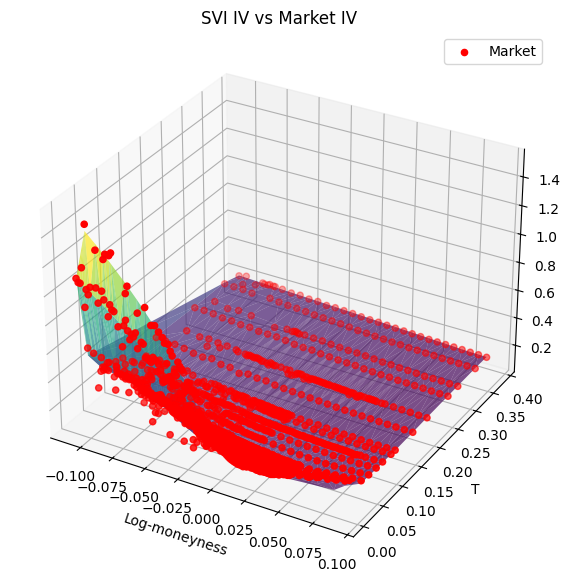

In [8]:
plot_surface_with_market(day_df, "svi_iv", "SVI IV vs Market IV")

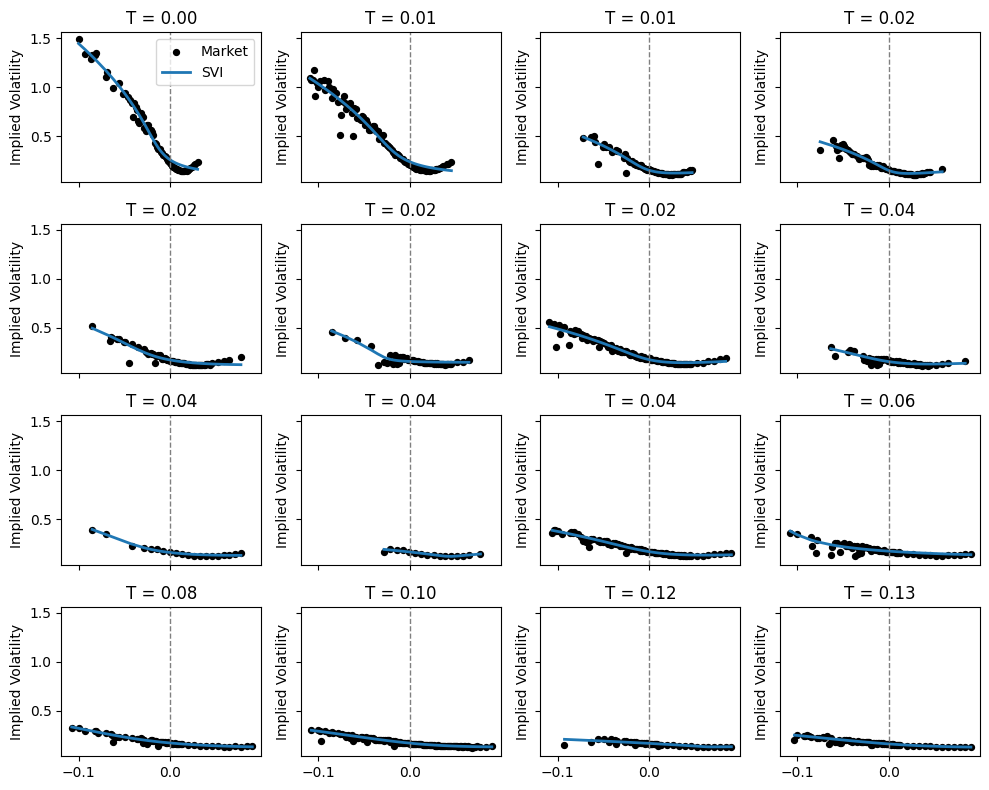

In [9]:
maturities = np.sort(day_df["T"].unique())

fig, axes = plt.subplots(4, 4, figsize=(10, 8), sharex=True, sharey=True)
axes = axes.flatten()

for ax, T in zip(axes, maturities):

    temp = (
        day_df[day_df["T"] == T]
        .sort_values("k")
    )

    ax.scatter(
        temp["k"],
        temp["IV"],
        color="black",
        s=18,
        label="Market"
    )

    ax.plot(
        temp["k"],
        temp["svi_iv"],
        lw=2,
        label="SVI"
    )

    ax.set_title(f"T = {T:.2f}")

    ax.set_ylabel("Implied Volatility")

    ax.axvline(
        0,
        color="gray",
        linestyle="--",
        linewidth=1
    )

axes[0].legend()


plt.tight_layout()
plt.show()

# 7. Calibration Performance

The calibration is evaluated using

- IV RMSE
- Vega-weighted RMSE
- ATM RMSE
- Near-wing RMSE
- Far-wing RMSE

These metrics quantify both overall fit quality and accuracy in the economically important ATM region.

In [10]:
rmse = {}
rmse_vega = {}
bucket_errors = {}

for date in dates:

    date_df = df[df["date"] == date][["k", "T", "underlying_price", "IV", "vega"]].copy()

    svi_df = (
        pd.Series(all_iv_svi[date], name="svi_iv")
        .rename_axis(["k", "T"])
        .reset_index()
    )

    date_df = date_df.merge(
        svi_df,
        on = ['k', 'T'],
        how = 'left'
    )


    err2 = (date_df["svi_iv"] - date_df["IV"]) ** 2

    rmse[date] = np.sqrt(np.mean(err2))

    rmse_vega[date] = np.sqrt(
        np.average(err2, weights=date_df["vega"])
    )

    date_df["moneyness_bucket"] = pd.cut(
        date_df["k"].abs(),
        bins=[0, 0.05, 0.1, np.inf],
        labels=["ATM", "Near-wing", "Far-wing"]
    )

    bucket_rmse = date_df.groupby("moneyness_bucket").apply(
        lambda x: np.sqrt(np.mean((x["svi_iv"] - x["IV"]) ** 2))
    )

    bucket_errors[date] = bucket_rmse

iv_results_df = pd.DataFrame({
    "date": rmse.keys(),
    "rmse": rmse.values(),
    "vega_rmse": rmse_vega.values(),
})

iv_bucket_df = (
    pd.DataFrame(bucket_errors)
      .T
      .reset_index()
      .rename(columns={"index": "date"})
)

iv_results_df = iv_results_df.merge(iv_bucket_df, on="date", how="left")

iv_results_df.drop(columns="date").mean()

rmse         0.030782
vega_rmse    0.016356
ATM          0.024710
Near-wing    0.039828
Far-wing     0.052888
dtype: float64

## Discussion

The calibration achieves:

- low ATM RMSE,
- very low vega-weighted RMSE,
- slightly larger errors in the wings.

This suggests that the SVI model captures the most liquid region of the smile particularly well while retaining a reasonable fit across the remaining strikes.

## Summary

The calibrated SVI surface closely reproduces observed market implied volatilities.

Performance is assessed using both global and moneyness-specific error metrics before comparing the model with alternative volatility surfaces through delta hedging experiments.